In [31]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.core.pylabtools import figsize
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

In [3]:
# GPU CPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# 데이터셋 경로 설정
celeba_dir = "./data/celeb_tiny/50k/"

In [5]:
class CelebADataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = os.path.join(img_dir, "celeba", "img_align_celeba")
        self.transform = transform
        self.img_names = os.listdir(self.img_dir)

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image


In [6]:
# 데이터 전처리
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [47]:
#celeba_data = datasets.CelebA(root=celeba_dir, split="all", transform=transform, download=True)
celeba_data = CelebADataset(img_dir=celeba_dir, transform=transform)
data_loader = DataLoader(dataset=celeba_data, batch_size=2048, shuffle=True)

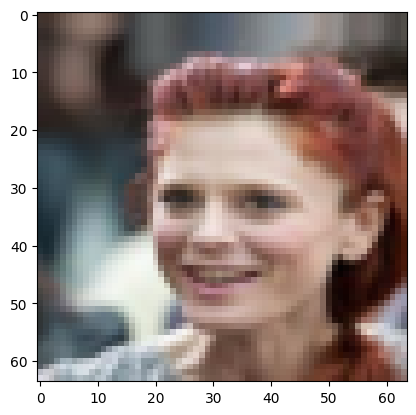

In [48]:
plt.imshow(celeba_data[1].permute(1, 2, 0))

In [49]:
class VAE(nn.Module):
    def __init__(self, input_channels, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
        )
        self.fc1 = nn.Linear(256*4*4, latent_dim) # 평균
        self.fc2 = nn.Linear(256*4*4, latent_dim) # 분산
        self.fc3 = nn.Linear(latent_dim, 256*4*4) # latent space내 latent variable
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, input_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.fc1(h), self.fc2(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return eps * std + mu

    def decode(self, z):
        h = self.fc3(z)
        h = h.view(h.size(0), 256, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [50]:
def loss_function_MSE(recon_x, x, mu, logvar):
    MSE = nn.functional.mse_loss(recon_x, x, reduction="sum")
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

In [51]:
def show_images(images):
    fig, axes = plt.subplots(1, len(images), figsize=(len(images)*2, 2))
    for img, ax in zip(images, axes):
        ax.imshow(img)
        ax.axis("off")
    plt.show()

In [52]:
def interpolate_latent_space(model, start, end, steps=10):
    vectors = []
    alpha_values = np.linspace(0, 1, steps)
    for alpha in alpha_values:
        vec = (1 - alpha) * start + alpha * end
        vectors.append(vec)
    vectors = torch.stack(vectors)
    return vectors

In [53]:
model = VAE(input_channels=3, hidden_dim=400, latent_dim=100).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [63]:
def train(epoch, loss_fn):
    start_time = time.time()
    model.train()
    train_loss = 0
    for batch_idx, data in enumerate(data_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_fn(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        print(f"[Batch {batch_idx+1:>4}/{len(data_loader)}] Loss: {loss.item() / len(data):.6f}")

    print(f"[Epoch: {epoch+1.:>4}] Loss: {train_loss / len(data_loader.dataset):.6f} Elapsed time: {time.time() - start_time:.2f}s")


In [64]:
loss_fn = loss_function_MSE
for epoch in range(10):
    train(epoch, loss_fn)

[Batch    1/99] Loss: 994.946655
[Batch    2/99] Loss: 979.807556
[Batch    3/99] Loss: 934.830261
[Batch    4/99] Loss: 903.180420
[Batch    5/99] Loss: 910.210999
[Batch    6/99] Loss: 894.992615
[Batch    7/99] Loss: 852.691040
[Batch    8/99] Loss: 876.241882
[Batch    9/99] Loss: 849.342346
[Batch   10/99] Loss: 833.417236
[Batch   11/99] Loss: 811.184692
[Batch   12/99] Loss: 799.301086
[Batch   13/99] Loss: 793.638916
[Batch   14/99] Loss: 795.336853
[Batch   15/99] Loss: 799.895691
[Batch   16/99] Loss: 792.974915
[Batch   17/99] Loss: 788.118164
[Batch   18/99] Loss: 780.625671
[Batch   19/99] Loss: 764.155212
[Batch   20/99] Loss: 775.256165
[Batch   21/99] Loss: 774.371643
[Batch   22/99] Loss: 760.510254
[Batch   23/99] Loss: 763.997498
[Batch   24/99] Loss: 751.331177
[Batch   25/99] Loss: 736.203491
[Batch   26/99] Loss: 738.820435
[Batch   27/99] Loss: 734.821045
[Batch   28/99] Loss: 730.238037
[Batch   29/99] Loss: 721.527161
[Batch   30/99] Loss: 730.173767
[Batch   3

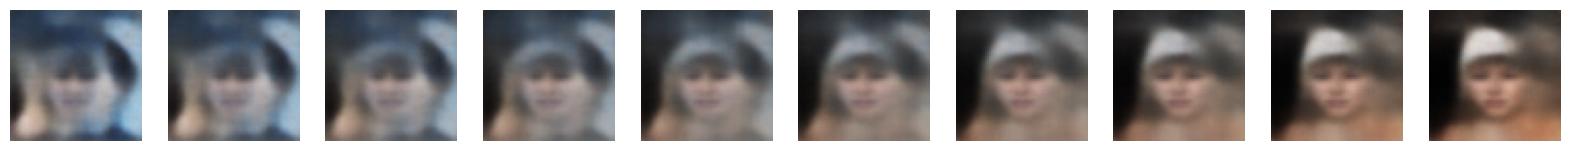

In [65]:
# 두 latent vector 사이 interpolation한 이미지
steps = 10
with torch.no_grad():
    z_start = torch.randn(1, 100).to(device)
    z_end = torch.randn(1, 100).to(device)
    interpolated_z = interpolate_latent_space(model, z_start, z_end, steps)
    samples = model.decode(interpolated_z).cpu()
    samples = samples.permute(0, 2, 3, 1).numpy()
    show_images([samples[i] for i in range(steps)])
    torch.cuda.empty_cache()

In [66]:
import gc
gc.collect()
torch.cuda.empty_cache()